In [19]:
!pip install joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ All libraries imported!')

✅ All libraries imported!



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
df = pd.read_csv('ds_salaries.csv')
print('Shape:', df.shape)
df.head()

Shape: (105434, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Analist,65664,EUR,69120,NL,0,NL,M
1,2025,EN,FT,Data Analist,47652,EUR,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,USD,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,USD,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M


In [21]:
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicates ===', df.duplicated().sum())
print('\n=== Columns ===', df.columns.tolist())
df.describe()

=== Missing Values ===
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

=== Duplicates === 52997

=== Columns === ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


,work_year,salary,salary_in_usd,remote_ratio
count,105434.000000,1.054340e+05,105434.000000,105434.000000
mean,2024.188981,1.626908e+05,158018.514179,21.103249
std,0.669665,2.137236e+05,74401.714026,40.714744
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.064000e+05,106400.000000,0.000000
50%,2024.000000,1.471000e+05,147000.000000,0.000000
75%,2025.000000,1.997000e+05,199000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


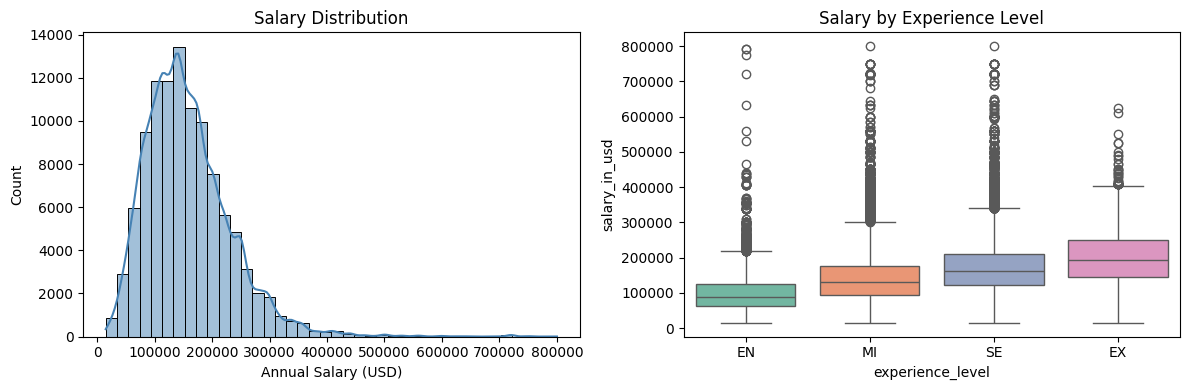

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['salary_in_usd'], bins=40, kde=True, color='steelblue')
plt.title('Salary Distribution')
plt.xlabel('Annual Salary (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='experience_level', y='salary_in_usd',
            order=['EN','MI','SE','EX'], palette='Set2')
plt.title('Salary by Experience Level')

plt.tight_layout()
plt.savefig('eda_salary.png', dpi=150)
plt.show()

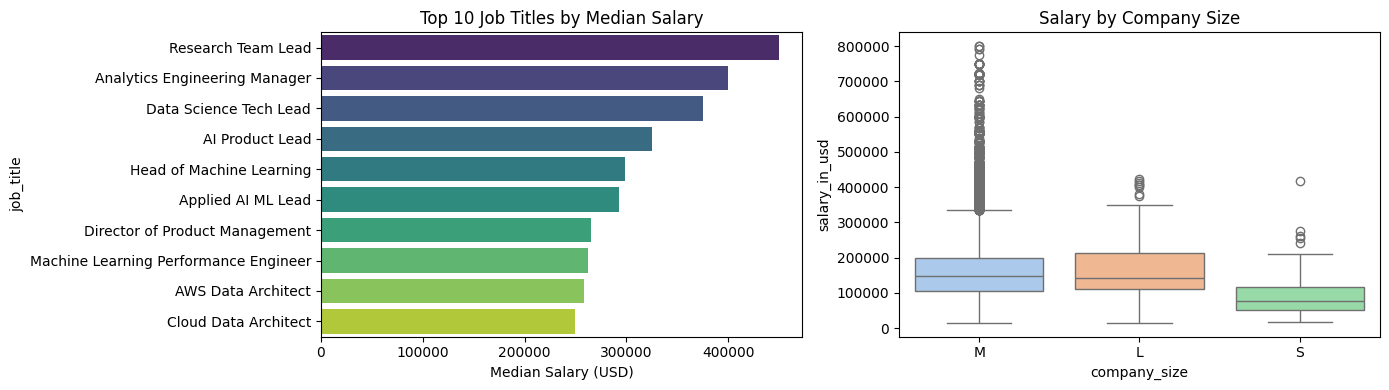

In [23]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
top_jobs = df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')
plt.title('Top 10 Job Titles by Median Salary')
plt.xlabel('Median Salary (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='company_size', y='salary_in_usd', palette='pastel')
plt.title('Salary by Company Size')

plt.tight_layout()
plt.savefig('eda_jobs.png', dpi=150)
plt.show()

In [24]:
# Select features
df_model = df[['work_year', 'experience_level', 'employment_type', 'job_title',
               'remote_ratio', 'company_size', 'salary_in_usd']].copy()

# Remove outliers (5th to 95th percentile)
Q1 = df_model['salary_in_usd'].quantile(0.05)
Q3 = df_model['salary_in_usd'].quantile(0.95)
df_model = df_model[(df_model['salary_in_usd'] >= Q1) & (df_model['salary_in_usd'] <= Q3)]
print(f'After outlier removal: {df_model.shape[0]} rows')

# Label Encoding
le_dict = {}
for col in ['experience_level', 'employment_type', 'job_title', 'company_size']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f'  {col}: {list(le.classes_)}')

print('\n✅ Preprocessing done!')

After outlier removal: 94899 rows
  experience_level: ['EN', 'EX', 'MI', 'SE']
  employment_type: ['CT', 'FL', 'FT', 'PT']
  job_title: ['AI Architect', 'AI Data Engineer', 'AI Data Scientist', 'AI Developer', 'AI Engineer', 'AI Engineering Manager', 'AI Governance Lead', 'AI Lead', 'AI Machine Learning Engineer', 'AI Product Lead', 'AI Product Manager', 'AI Product Owner', 'AI Programmer', 'AI Research Engineer', 'AI Research Scientist', 'AI Researcher', 'AI Scientist', 'AI Software Engineer', 'AI Solution Architect', 'AI Specialist', 'AI Tech Lead', 'AWS Data Architect', 'Account Executive', 'Actuarial Analyst', 'Admin & Data Analyst', 'Algorithm Developer', 'Analyst', 'Analytics Engineer', 'Analytics Lead', 'Analytics Specialist', 'Application Developer', 'Applied AI ML Lead', 'Applied Data Scientist', 'Applied Machine Learning Engineer', 'Applied Machine Learning Scientist', 'Applied Research Scientist', 'Applied Scientist', 'Architect', 'Artificial Intelligence Engineer', 'Associa

In [25]:
X = df_model.drop('salary_in_usd', axis=1)
y = df_model['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('✅ Split and scaling done!')

Train: 75919 | Test: 18980
✅ Split and scaling done!


In [26]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print('✅ Linear Regression trained!')

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print('✅ Random Forest trained!')

✅ Linear Regression trained!
✅ Random Forest trained!


In [27]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print('✅ Linear Regression trained!')

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print('✅ Random Forest trained!')

✅ Linear Regression trained!
✅ Random Forest trained!


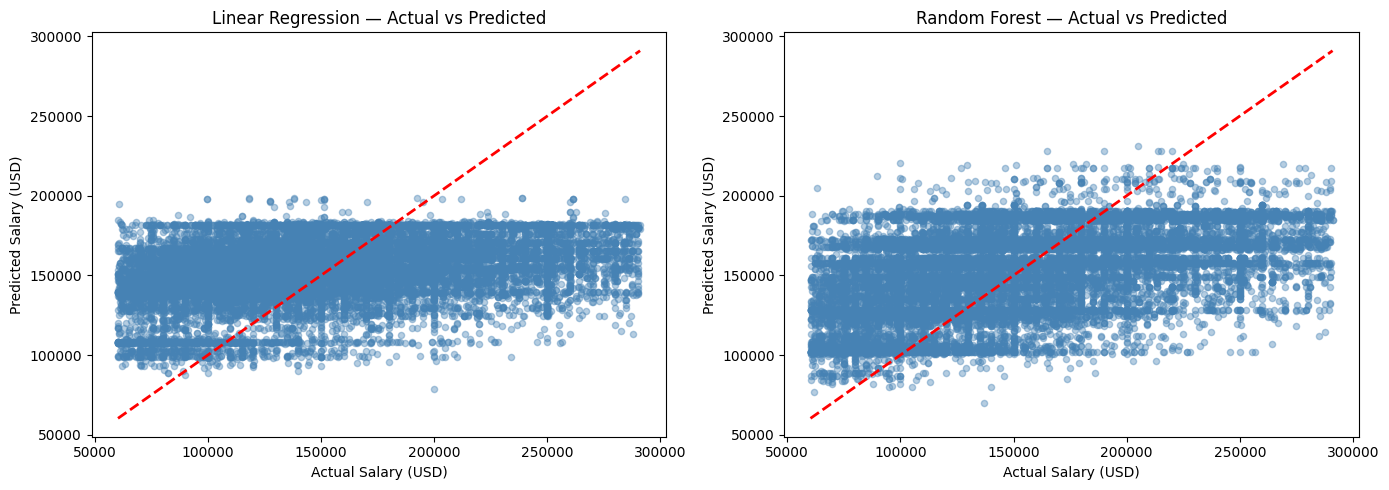

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(axes,
                            [y_pred_lr, y_pred_rf],
                            ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.4, s=20, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_title(f'{name} — Actual vs Predicted')
    ax.set_xlabel('Actual Salary (USD)')
    ax.set_ylabel('Predicted Salary (USD)')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

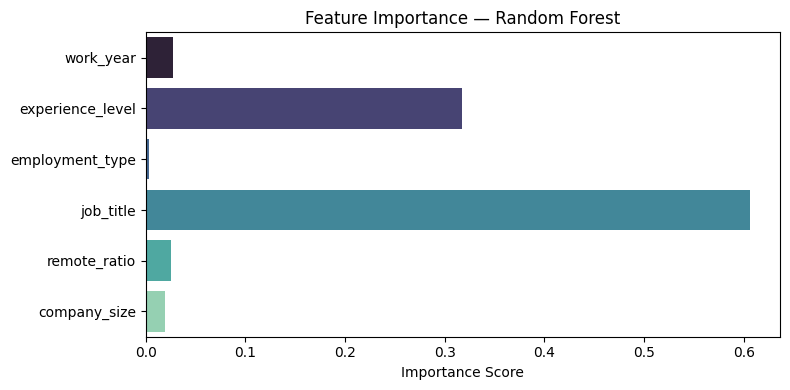

In [29]:
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=feature_names, palette='mako')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [31]:
joblib.dump(rf_model,    'salary_model.pkl')
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(le_dict,     'label_encoders.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print('✅ All files saved!')



✅ All files saved!


In [32]:
sample = pd.DataFrame([{
    'work_year': 2022,
    'experience_level': le_dict['experience_level'].transform(['SE'])[0],
    'employment_type':  le_dict['employment_type'].transform(['FT'])[0],
    'job_title':        le_dict['job_title'].transform(['Data Scientist'])[0],
    'remote_ratio':     100,
    'company_size':     le_dict['company_size'].transform(['M'])[0],
}])

pred = rf_model.predict(sample)[0]
print(f'🎯 Senior Data Scientist | Remote | Medium Company')
print(f'   Annual Salary  : ${pred:,.0f} USD')
print(f'   Monthly Salary : ${pred/12:,.0f} USD')

🎯 Senior Data Scientist | Remote | Medium Company
   Annual Salary  : $163,642 USD
   Monthly Salary : $13,637 USD
